# Advanced Forecasting Foundation Models & Cutting-Edge Methods

The frontier of time series forecasting in 2024-2025 is dominated by:
1. **Transformer-based** specialist forecasters
2. **Foundation models** for zero-shot forecasting
3. **Probabilistic forecasting** with uncertainty quantification
4. **Hierarchical forecasting** for structured collections of series

## Transformer-Based Forecasters

| Model | Year | Key Innovation |
|-------|------|----------------|
| Informer | 2021 | ProbSparse attention, $O(L \log L)$ |
| Autoformer | 2021 | Autocorrelation-based attention + decomposition |
| FEDformer | 2022 | Frequency-enhanced attention |
| PatchTST | 2023 | Patching + channel independence |
| iTransformer | 2024 | Inverted attention token = one variate |
| TimeMixer | 2024 | Multi-resolution mixing |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("Advanced Forecasting Models Overview")
print("=" * 50)

Advanced Forecasting Models Overview


## Informer Efficient Transformer for Long Sequences

Standard Transformer attention is $O(L^2)$ infeasible for long series. Informer introduces:

### ProbSparse Self-Attention
Select top-$u = O(\ln L)$ queries based on a sparsity measurement:
$$M(\mathbf{q}_i, \mathbf{K}) = \ln \sum_{j=1}^{L_k} e^{\frac{\mathbf{q}_i \mathbf{k}_j^T}{\sqrt{d}}} - \frac{1}{L_k} \sum_{j=1}^{L_k} \frac{\mathbf{q}_i \mathbf{k}_j^T}{\sqrt{d}}$$

Complexity: $O(L \log L)$ in both time and memory.

### Self-Attention Distilling
Halve sequence length between encoder layers using max-pooling:
$$\mathbf{X}_{j+1}^t = \text{MaxPool}(\text{ELU}(\text{Conv1d}(\mathbf{X}_j^t)))$$

## Autoformer Decomposition + Autocorrelation

Autoformer replaces standard attention with **autocorrelation-based attention** that leverages the period nature of time series.

### Series Decomposition Block (used throughout the model):
$$\mathcal{X}_{\text{trend}} = \text{AvgPool}(\text{Padding}(\mathcal{X}))$$
$$\mathcal{X}_{\text{seasonal}} = \mathcal{X} - \mathcal{X}_{\text{trend}}$$

### Auto-Correlation Mechanism:
$$R_{\mathcal{Q},\mathcal{K}}(\tau) = \mathcal{F}^{-1}(\mathcal{F}(\mathcal{Q}) \odot \overline{\mathcal{F}(\mathcal{K})})$$

Computed via FFT in $O(L \log L)$. Top-$k$ delays are used for aggregation.

## Time Series Foundation Models

Foundation models are **pre-trained on massive corpora** of time series and can perform **zero-shot forecasting** without any fine-tuning.

| Model | Organisation | Training Data | Architecture |
|-------|-------------|---------------|-------------|
| TimesFM | Google DeepMind | 100B time points | Decoder-only Transformer |
| Chronos | Amazon | Large scale | T5 language model |
| Moirai | Salesforce | LOTSA dataset | Unified Training |
| MOMENT | CMU | MIMIC + others | Encoder Transformer |
| Lag-Llama | ServiceNow | 27 datasets | LLaMA-based |
| UniTS | Various | Multi-task | Shared Transformer |

## TimesFM (Google DeepMind, 2024)

TimesFM is a **200M parameter** time-series foundation model trained on 100 billion real-world time points.

### Architecture
- **Input:** patches of length 32 (like PatchTST)
- **Backbone:** stacked residual blocks with attention
- **Output:** quantile forecasts at multiple horizons
- **Point + quantile output:** $\hat{y}_{t+h}$ + $(q_{10}, q_{50}, q_{90})$

$$\text{Paper: https://arxiv.org/abs/2310.10688}$$

In [2]:
# TimesFM usage
try:
    import timesfm
    
    tfm = timesfm.TimesFm(
        hparams=timesfm.TimesFmHparams(
            backend='cpu',
            per_core_batch_size=32,
            horizon_len=128,
        ),
        checkpoint=timesfm.TimesFmCheckpoint(
            huggingface_repo_id='google/timesfm-1.0-200m'
        )
    )
    tfm.load_from_checkpoint()
    
    # Zero-shot forecast
    from statsmodels.datasets import get_rdataset
    data = get_rdataset('AirPassengers').data['value'].values
    
    point_fc, quantile_fc = tfm.forecast(
        inputs=[data[:120]],
        freq=[0]  # 0=high_freq, 1=medium, 2=low
    )
    print(f"Zero-shot forecast shape: {point_fc.shape}")

except ImportError:
    print("Install: pip install timesfm")
    print("GitHub: https://github.com/google-research/timesfm")
    print("Paper:  https://arxiv.org/abs/2310.10688")

Install: pip install timesfm
GitHub: https://github.com/google-research/timesfm
Paper:  https://arxiv.org/abs/2310.10688


## Chronos (Amazon, 2024)

Chronos reframes time series forecasting as a **language modeling task** by quantising values into tokens.

### Key Ideas:
1. **Tokenisation:** normalise series, then discretise into $B$ bins
   $$q_k = \text{quantile}(\text{scale}(y), k/B), \quad k = 1,\ldots,B$$
2. **Model:** T5 (encoder-decoder transformer) or GPT2 (decoder-only)
3. **Training:** next-token prediction on quantised tokens
4. **Inference:** autoregressive generation → histogram → point forecast

Models sizes: Tiny (8M), Mini (20M), Small (46M), Base (200M), Large (710M)

In [3]:
try:
    import torch
    from chronos import ChronosPipeline
    
    pipeline = ChronosPipeline.from_pretrained(
        'amazon/chronos-t5-small',
        device_map='cpu',
        torch_dtype=torch.float32
    )
    
    from statsmodels.datasets import get_rdataset
    data = get_rdataset('AirPassengers').data['value'].values
    context = torch.tensor(data[:120], dtype=torch.float32)
    
    # Zero-shot forecast with uncertainty
    forecast = pipeline.predict(context=context, prediction_length=24, num_samples=20)
    
    median = forecast.median(dim=1).values.squeeze().numpy()
    low    = forecast.quantile(0.1, dim=1).squeeze().numpy()
    high   = forecast.quantile(0.9, dim=1).squeeze().numpy()
    
    plt.figure(figsize=(12, 5))
    plt.plot(data, label='Actual', color='black')
    plt.plot(range(120, 144), median, label='Chronos Median', color='blue')
    plt.fill_between(range(120, 144), low, high, alpha=0.3, label='80% PI')
    plt.axvline(120, color='gray', linestyle=':')
    plt.legend()
    plt.title('Chronos Zero-Shot Forecast')
    plt.show()

except ImportError:
    print("Install: pip install git+https://github.com/amazon-science/chronos-forecasting.git")
    print("Paper:   https://arxiv.org/abs/2403.07815")

Install: pip install git+https://github.com/amazon-science/chronos-forecasting.git
Paper:   https://arxiv.org/abs/2403.07815


## Probabilistic Forecasting

Instead of point forecasts, produce **full predictive distributions** $p(y_{t+h} | y_{1:t})$.

### DeepAR (Amazon)
Autoregressive RNN that outputs parameters of a probability distribution:
$$p(y_{t+1:t+T} | y_{1:t}) = \prod_{\tau=1}^{T} p(y_{t+\tau} | \theta(h_{t+\tau}))$$

where $h_{t+\tau}$ = LSTM hidden state, $\theta$ = distribution parameters.
- Gaussian: $\theta = (\mu, \sigma)$
- Negative Binomial (count data): $\theta = (\mu, \alpha)$
- Student-t: $\theta = (\nu, \mu, \sigma)$

### Quantile Regression
Directly estimate quantiles by minimising **pinball loss**:
$$\mathcal{L}_q(y, \hat{y}) = \begin{cases} q(y - \hat{y}) & \text{if } y \geq \hat{y} \\ (1-q)(\hat{y} - y) & \text{if } y < \hat{y} \end{cases}$$

### Conformal Prediction
Distribution-free prediction intervals with guaranteed coverage:
$$\hat{C}_{\alpha}(x) = [\hat{y} - q_{1-\alpha}(|r_1|, \ldots, |r_n|),\ \hat{y} + q_{1-\alpha}(|r_1|, \ldots, |r_n|)]$$

where $r_i = y_i - \hat{y}_i$ are calibration residuals.

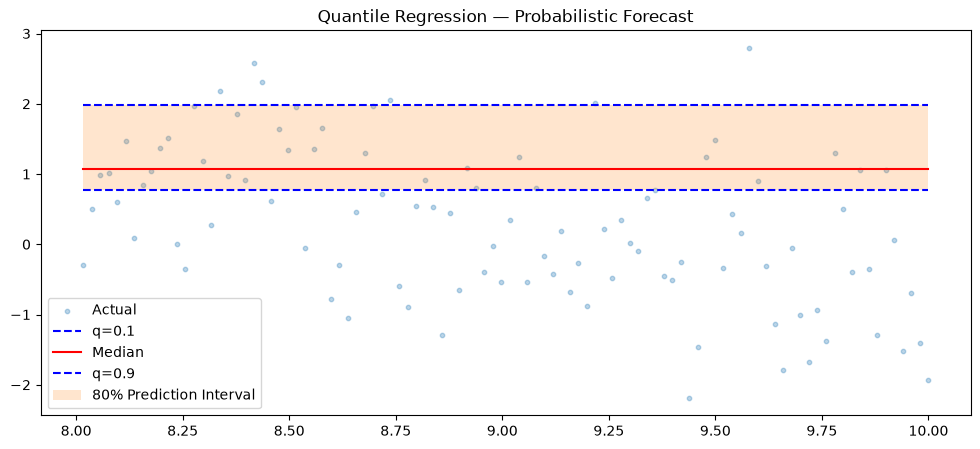

In [4]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split

# Quantile regression with GBR
np.random.seed(42)
n = 500
X = np.linspace(0, 10, n).reshape(-1, 1)
y = np.sin(X.ravel()) + 0.5 * np.random.randn(n) * (X.ravel() / 5)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

quantiles = [0.1, 0.5, 0.9]
models = {}
for q in quantiles:
    gbr = GradientBoostingRegressor(loss='quantile', alpha=q,
                                     n_estimators=200, max_depth=4, learning_rate=0.05)
    gbr.fit(X_train, y_train)
    models[q] = gbr

plt.figure(figsize=(12, 5))
plt.scatter(X_test, y_test, alpha=0.3, s=10, label='Actual')
for q, color in zip([0.1, 0.5, 0.9], ['blue', 'red', 'blue']):
    pred = models[q].predict(X_test)
    lbl  = f'q={q}' if q != 0.5 else 'Median'
    plt.plot(X_test, pred, label=lbl, color=color,
             linestyle='--' if q != 0.5 else '-')
plt.fill_between(X_test.ravel(),
                 models[0.1].predict(X_test),
                 models[0.9].predict(X_test),
                 alpha=0.2, label='80% Prediction Interval')
plt.legend()
plt.title('Quantile Regression Probabilistic Forecast')
plt.show()

## Hierarchical Forecasting

In retail, economics, and organisations, time series are often structured **hierarchically**:

```
Total Sales
├── Region A
│   ├── Store A1
│   └── Store A2
└── Region B
    ├── Store B1
    └── Store B2
```

**Constraint:** forecasts must be coherent: $\hat{y}_{\text{Total}} = \hat{y}_{A} + \hat{y}_{B}$

### Reconciliation Approaches
1. **Bottom-Up:** forecast leaf nodes, sum up
2. **Top-Down:** forecast top, disaggregate proportionally
3. **Middle-Out:** forecast intermediate, combine both
4. **MinT (Minimum Trace):** optimal linear reconciliation:
$$\tilde{\mathbf{y}} = \mathbf{S}(\mathbf{S}^T \mathbf{W}^{-1} \mathbf{S})^{-1} \mathbf{S}^T \mathbf{W}^{-1} \hat{\mathbf{y}}$$

where $\mathbf{S}$ is the summing matrix and $\mathbf{W}$ is the error covariance.

## Forecasting Evaluation Metrics

| Metric | Formula | Notes |
|--------|---------|-------|
| MAE | $\frac{1}{H}\sum|y_t - \hat{y}_t|$ | Scale-dependent |
| RMSE | $\sqrt{\frac{1}{H}\sum(y_t - \hat{y}_t)^2}$ | Penalises large errors |
| MAPE | $\frac{100}{H}\sum\left|\frac{y_t - \hat{y}_t}{y_t}\right|$ | Scale-free, fails near zero |
| SMAPE | $\frac{200}{H}\sum\frac{|y_t - \hat{y}_t|}{|y_t| + |\hat{y}_t|}$ | Symmetric MAPE |
| MASE | $\frac{MAE}{\frac{1}{n-m}\sum_{t=m+1}^{n}|y_t - y_{t-m}|}$ | Scale-free, handles zeros |
| CRPS | $\int_{-\infty}^{\infty}(F(y) - \mathbf{1}(y \geq y_t))^2 dy$ | Probabilistic score |

**MASE** (Mean Absolute Scaled Error) is preferred for comparing across series.

---

## Additional Learning Resources

### Papers
- **TimesFM** A decoder-only foundation model: https://arxiv.org/abs/2310.10688
- **Chronos** LLM for time series: https://arxiv.org/abs/2403.07815
- **Moirai** Salesforce foundation model: https://arxiv.org/abs/2402.02592
- **Lag-Llama** LLaMA-based forecasting: https://arxiv.org/abs/2310.08278
- **Informer** ProbSparse attention: https://arxiv.org/abs/2012.07436
- **Autoformer** Decomposition Transformer: https://arxiv.org/abs/2106.13008
- **iTransformer** Inverted Transformer: https://arxiv.org/abs/2310.06625
- **DeepAR** Probabilistic forecasting: https://arxiv.org/abs/1704.04110
- **MinT** Optimal reconciliation: https://robjhyndman.com/papers/MinT.pdf

### Libraries
- NeuralForecast (Nixtla): https://nixtlaverse.nixtla.io/neuralforecast/
- StatsForecast (Nixtla): https://nixtlaverse.nixtla.io/statsforecast/
- GluonTS: https://ts.gluon.ai/
- Darts: https://unit8co.github.io/darts/
- HierarchicalForecast (Nixtla): https://nixtlaverse.nixtla.io/hierarchicalforecast/

### Benchmarks
- Monash Forecasting Archive: https://forecastingdata.org/
- M-Competitions: https://mofc.unic.ac.cy/m-competitions/